# Model 2 Face Recognition Analysis

This notebook profiles the dataset, documents the EfficientNetV2B0 transfer-learning pipeline, and evaluates how well the kiosk face classifier separates the two known identities.

It is structured so you can either:
- analyze the already-saved model immediately, or
- switch on retraining and generate a fresh model run from the same notebook.


## 1. Installation and Configuration

This section checks the environment and sets the switches that control whether we retrain the model or reuse the saved one.

If you are missing packages, uncomment the install line in the next cell and run it once.


In [27]:
# %pip install tensorflow numpy pandas matplotlib pillow

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from PIL import Image

plt.style.use("seaborn-v0_8-whitegrid")
tf.keras.utils.set_random_seed(42)
np.set_printoptions(suppress=True, precision=4)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


TensorFlow version: 2.20.0
NumPy version: 2.4.4
Pandas version: 2.3.0


In [28]:
def locate_backend_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "backend" / "dataset").exists() and (candidate / "backend" / "models").exists():
            return candidate / "backend"
        if (candidate / "dataset").exists() and (candidate / "models").exists():
            return candidate
    raise FileNotFoundError("Could not find the backend folder that contains dataset/ and models/.")


BACKEND_DIR = locate_backend_root()
TRAIN_DIR = BACKEND_DIR / "dataset" / "train"
VAL_DIR = BACKEND_DIR / "dataset" / "value"
MODEL_SAVE_PATH = BACKEND_DIR / "models" / "kiosk_face_model_eff.keras"
ARTIFACT_DIR = BACKEND_DIR / "scripts" / "training" / "artifacts" / "model_2_analysis"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 5
SEED = 42

TRAIN_MODEL = False
SAVE_MODEL_AFTER_TRAINING = True
ENABLE_FINE_TUNING = False

REFERENCE_HISTORY = {
    "accuracy": [0.7354, 0.9479, 0.9646, 0.9646, 0.9812, 0.9771, 0.9854, 0.9875, 0.9896, 0.9854],
    "val_accuracy": [0.9833, 0.9750, 0.9833, 0.9833, 0.9917, 0.9917, 0.9917, 0.9917, 0.9917, 0.9917],
    "loss": [0.5408, 0.2730, 0.1923, 0.1526, 0.1120, 0.1189, 0.0812, 0.0754, 0.0725, 0.0736],
    "val_loss": [0.3176, 0.1837, 0.1170, 0.0906, 0.0723, 0.0622, 0.0544, 0.0487, 0.0433, 0.0397],
}

print(f"Backend directory: {BACKEND_DIR}")
print(f"Train directory:   {TRAIN_DIR}")
print(f"Val directory:     {VAL_DIR}")
print(f"Model path:        {MODEL_SAVE_PATH}")
print(f"Artifact folder:   {ARTIFACT_DIR}")
print(f"TRAIN_MODEL:       {TRAIN_MODEL}")
print(f"ENABLE_FINE_TUNING:{ENABLE_FINE_TUNING}")


Backend directory: C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend
Train directory:   C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\dataset\train
Val directory:     C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\dataset\value
Model path:        C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\models\kiosk_face_model_eff.keras
Artifact folder:   C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\scripts\training\artifacts\model_2_analysis
TRAIN_MODEL:       False
ENABLE_FINE_TUNING:False


## 2. Data Audit and Visual Profiling

Before training or evaluating the model, we should understand what the dataset looks like. Good face-classification performance is easier to trust when class counts are balanced, image sizes are consistent, and train/validation images have similar visual characteristics.


In [29]:
def save_figure(fig, filename: str) -> Path:
    output_path = ARTIFACT_DIR / filename
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    return output_path


def merge_histories(first_history: dict, second_history: dict) -> dict:
    merged = {key: list(values) for key, values in first_history.items()}
    for key, values in second_history.items():
        merged.setdefault(key, [])
        merged[key].extend(list(values))
    return merged


def collect_image_records(split_dir: Path, split_name: str) -> list[dict]:
    records = []
    for class_dir in sorted([path for path in split_dir.iterdir() if path.is_dir()]):
        for image_path in sorted(class_dir.glob("*")):
            if not image_path.is_file():
                continue
            with Image.open(image_path) as image:
                rgb_image = image.convert("RGB")
                pixel_array = np.asarray(rgb_image, dtype=np.float32) / 255.0
                records.append({
                    "split": split_name,
                    "class_name": class_dir.name,
                    "file_path": str(image_path),
                    "file_name": image_path.name,
                    "width": rgb_image.size[0],
                    "height": rgb_image.size[1],
                    "mean_intensity": float(pixel_array.mean()),
                    "pixel_std": float(pixel_array.std()),
                })
    return records


def build_confusion_matrix(true_labels: np.ndarray, predicted_labels: np.ndarray, class_count: int) -> np.ndarray:
    matrix = np.zeros((class_count, class_count), dtype=int)
    for true_label, predicted_label in zip(true_labels, predicted_labels):
        matrix[true_label, predicted_label] += 1
    return matrix


def build_class_metrics(true_labels: np.ndarray, predicted_labels: np.ndarray, class_names: list[str]) -> pd.DataFrame:
    rows = []
    for class_index, class_name in enumerate(class_names):
        true_positive = int(np.sum((true_labels == class_index) & (predicted_labels == class_index)))
        false_negative = int(np.sum((true_labels == class_index) & (predicted_labels != class_index)))
        false_positive = int(np.sum((true_labels != class_index) & (predicted_labels == class_index)))
        support = int(np.sum(true_labels == class_index))
        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) else 0.0
        recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) else 0.0
        f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
        rows.append({"class_name": class_name, "support": support, "precision": precision, "recall": recall, "f1_score": f1_score})
    return pd.DataFrame(rows)


def plot_confusion_matrix(ax, matrix: np.ndarray, class_names: list[str], title: str) -> None:
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    for row_index in range(matrix.shape[0]):
        for col_index in range(matrix.shape[1]):
            ax.text(col_index, row_index, matrix[row_index, col_index], ha="center", va="center", color="black")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


,split,class_name,image_count
0,train,anton,240
1,train,anton2,240
2,validation,anton,60
3,validation,anton2,60


width             height            
             min  max   mean    min  max   mean
split                                          
train        224  224  224.0    224  224  224.0
validation   224  224  224.0    224  224  224.0

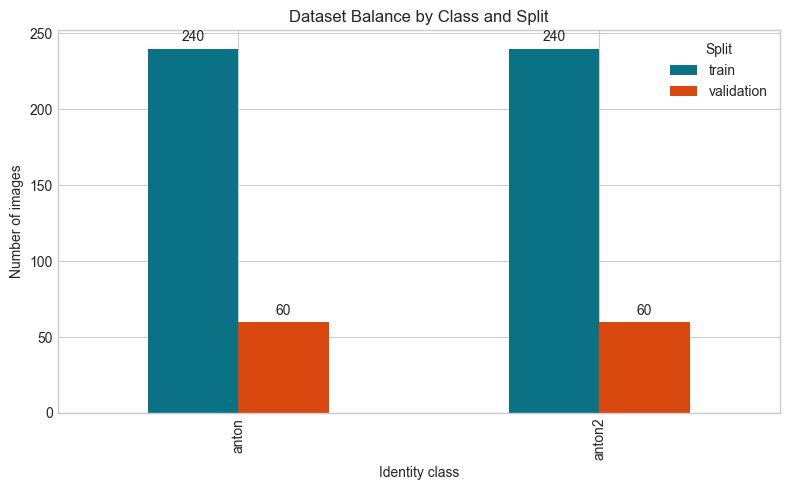

Interpretation: bars with very similar heights mean the classifier is learning from a balanced dataset instead of from class frequency bias.


In [30]:
train_records = collect_image_records(TRAIN_DIR, "train")
val_records = collect_image_records(VAL_DIR, "validation")
image_df = pd.DataFrame(train_records + val_records)

class_names = sorted(image_df["class_name"].unique().tolist())
class_count_summary = (
    image_df.groupby(["split", "class_name"])
    .size()
    .reset_index(name="image_count")
    .sort_values(["split", "class_name"])
)
resolution_summary = image_df.groupby("split")[["width", "height"]].agg(["min", "max", "mean"]).round(2)

display(class_count_summary)
display(resolution_summary)

pivot_counts = class_count_summary.pivot(index="class_name", columns="split", values="image_count").fillna(0)
fig, ax = plt.subplots(figsize=(8, 5))
pivot_counts.plot(kind="bar", ax=ax, color=["#0b7285", "#d9480f"])
ax.set_title("Dataset Balance by Class and Split")
ax.set_xlabel("Identity class")
ax.set_ylabel("Number of images")
ax.legend(title="Split")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.tight_layout()
save_figure(fig, "dataset_class_balance.png")
plt.show()

print("Interpretation: bars with very similar heights mean the classifier is learning from a balanced dataset instead of from class frequency bias.")


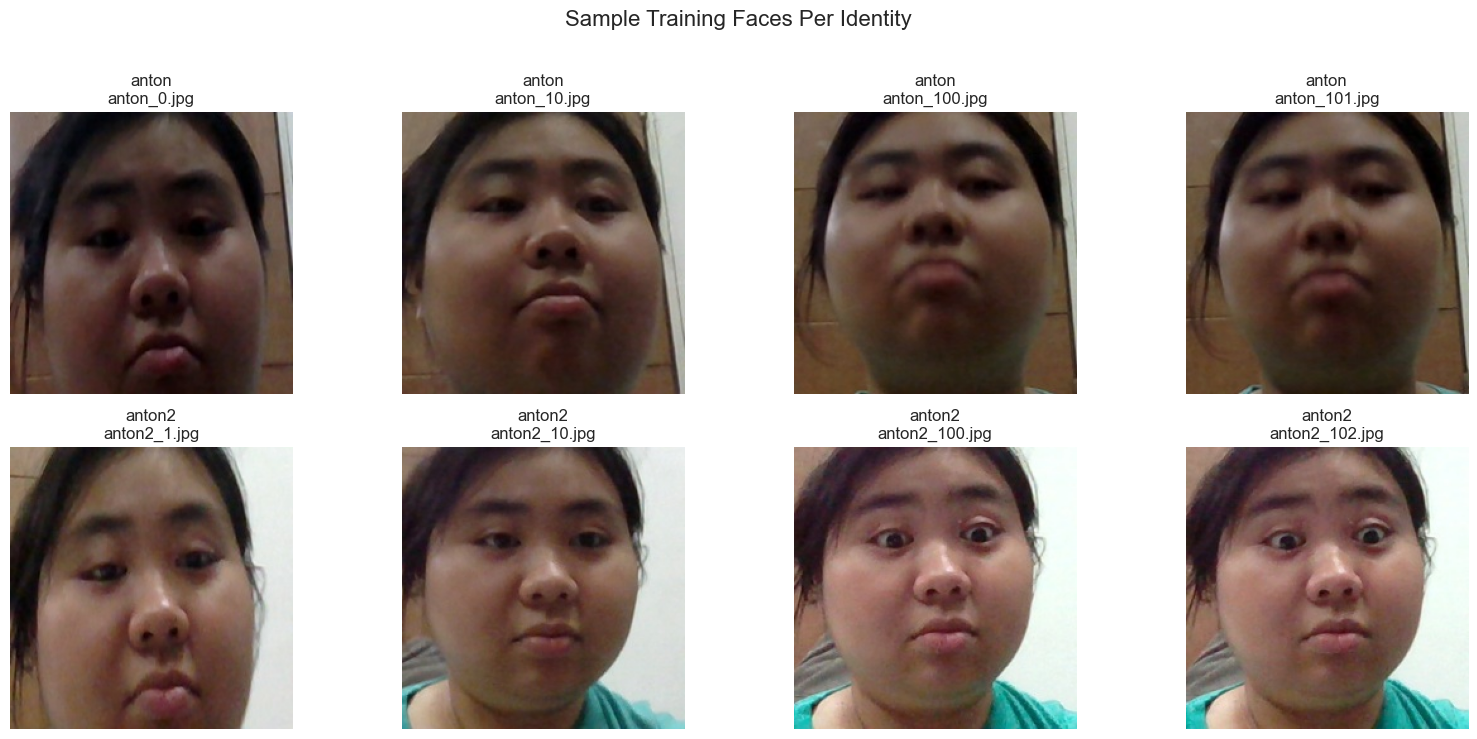

Interpretation: this gallery helps you visually inspect pose, crop quality, background variation, and whether the two classes are distinct enough for a classifier to separate.


In [31]:
samples_per_class = 4
fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(4 * samples_per_class, 3.6 * len(class_names)))
if len(class_names) == 1:
    axes = np.array([axes])

for row_index, class_name in enumerate(class_names):
    sample_rows = image_df[(image_df["split"] == "train") & (image_df["class_name"] == class_name)].head(samples_per_class)
    for col_index, (_, sample_row) in enumerate(sample_rows.iterrows()):
        with Image.open(sample_row["file_path"]) as image:
            axes[row_index, col_index].imshow(image)
        axes[row_index, col_index].set_title(f"{class_name}\n{sample_row['file_name']}")
        axes[row_index, col_index].axis("off")
    for col_index in range(len(sample_rows), samples_per_class):
        axes[row_index, col_index].axis("off")

fig.suptitle("Sample Training Faces Per Identity", fontsize=16, y=1.02)
plt.tight_layout()
save_figure(fig, "sample_faces_grid.png")
plt.show()

print("Interpretation: this gallery helps you visually inspect pose, crop quality, background variation, and whether the two classes are distinct enough for a classifier to separate.")


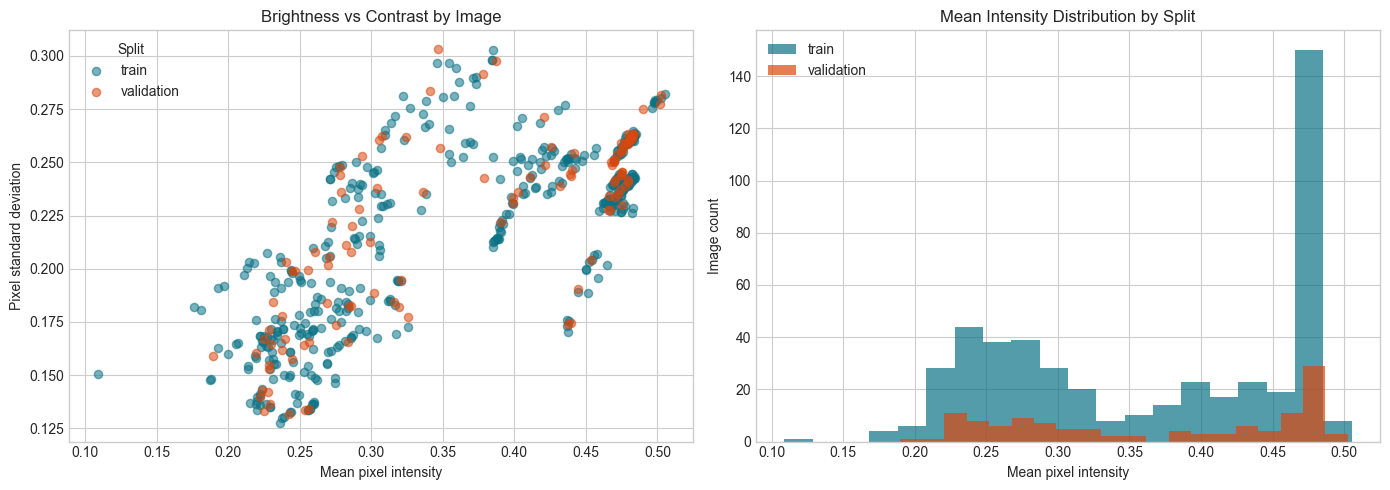

mean_intensity         pixel_std        
                     mean     std      mean     std
split                                              
train              0.3662  0.1020    0.2186  0.0422
validation         0.3688  0.1008    0.2216  0.0425

Interpretation: when the train and validation points overlap well, it suggests consistent preprocessing and similar lighting conditions across both splits.
Interpretation: isolated outliers can reveal unusually dark, bright, blurry, or low-contrast images that may be harder for the model to classify.


In [32]:
color_map = {"train": "#0b7285", "validation": "#d9480f"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for split_name, split_frame in image_df.groupby("split"):
    axes[0].scatter(split_frame["mean_intensity"], split_frame["pixel_std"], alpha=0.55, s=35, label=split_name, color=color_map[split_name])
axes[0].set_title("Brightness vs Contrast by Image")
axes[0].set_xlabel("Mean pixel intensity")
axes[0].set_ylabel("Pixel standard deviation")
axes[0].legend(title="Split")

axes[1].hist(image_df.loc[image_df["split"] == "train", "mean_intensity"], bins=20, alpha=0.7, label="train", color=color_map["train"])
axes[1].hist(image_df.loc[image_df["split"] == "validation", "mean_intensity"], bins=20, alpha=0.7, label="validation", color=color_map["validation"])
axes[1].set_title("Mean Intensity Distribution by Split")
axes[1].set_xlabel("Mean pixel intensity")
axes[1].set_ylabel("Image count")
axes[1].legend()

plt.tight_layout()
save_figure(fig, "image_statistics.png")
plt.show()

display(image_df.groupby("split")[["mean_intensity", "pixel_std"]].agg(["mean", "std"]).round(4))
print("Interpretation: when the train and validation points overlap well, it suggests consistent preprocessing and similar lighting conditions across both splits.")
print("Interpretation: isolated outliers can reveal unusually dark, bright, blurry, or low-contrast images that may be harder for the model to classify.")


## 3. Data Loading Pipeline

This section creates TensorFlow datasets for both training and validation. Caching and prefetching keep the pipeline responsive, while the validation dataset is kept in a fixed order so our later prediction analysis lines up with the original files.


In [33]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(TRAIN_DIR, shuffle=False, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE)
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(VAL_DIR, shuffle=False, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE)

class_names = train_dataset.class_names
num_classes = len(class_names)
train_file_count = len(train_records)
val_file_count = len(val_records)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(train_file_count, seed=SEED).prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
val_eval_dataset = tf.keras.preprocessing.image_dataset_from_directory(VAL_DIR, shuffle=False, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE).cache().prefetch(AUTOTUNE)

example_images, example_labels = next(iter(train_dataset.take(1)))
print(f"Detected classes: {class_names}")
print(f"One batch shape: {example_images.shape}")
print(f"One label batch shape: {example_labels.shape}")


Found 480 files belonging to 2 classes.
Found 120 files belonging to 2 classes.
Found 120 files belonging to 2 classes.
Detected classes: ['anton', 'anton2']
One batch shape: (32, 224, 224, 3)
One label batch shape: (32,)


## 4. Transfer Learning Architecture

The model uses EfficientNetV2B0 pre-trained on ImageNet as a frozen feature extractor. This is why the notebook performs well even with a relatively small face dataset: the backbone already knows how to encode strong visual patterns such as edges, textures, and facial structure.

The custom head is intentionally small, which reduces overfitting risk and makes the model adapt to your two identity classes without retraining millions of parameters.


In [34]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

print("Loading EfficientNetV2B0 backbone...")
base_model = tf.keras.applications.EfficientNetV2B0(input_shape=IMAGE_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="kiosk_face_model_eff")
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()
print("Interpretation: freezing the backbone means only the lightweight classification head learns at first, which is efficient and usually stable on small datasets.")


Loading EfficientNetV2B0 backbone...


Model: "kiosk_face_model_eff"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921,874 (22.59 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Interpretation: freezing the backbone means only the lightweight classification head learns at first, which is efficient and usually stable on small datasets.


## 5. Training Strategy

This section supports two modes:
- `TRAIN_MODEL = False`: skip retraining and analyze the saved model immediately.
- `TRAIN_MODEL = True`: train from scratch, optionally followed by controlled fine-tuning.

The callbacks below are practical optimizations because they stop wasted epochs, reduce the learning rate when progress plateaus, and preserve the best checkpoint. The model is also saved in the file path in order to 


In [35]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
]

history_records = {key: list(values) for key, values in REFERENCE_HISTORY.items()}
history_source = "reference history from the current saved model"

if TRAIN_MODEL:
    print("Training from scratch...")
    training_history = model.fit(train_dataset, validation_data=val_dataset, epochs=INITIAL_EPOCHS, callbacks=callbacks, verbose=1)
    history_records = {key: list(values) for key, values in training_history.history.items()}
    history_source = "fresh training run from this notebook"

    if ENABLE_FINE_TUNING:
        print("Starting controlled fine-tuning...")
        base_model.trainable = True
        for layer in base_model.layers[:-20]:
            layer.trainable = False
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        fine_tune_history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            initial_epoch=len(history_records["accuracy"]),
            epochs=len(history_records["accuracy"]) + FINE_TUNE_EPOCHS,
            callbacks=callbacks,
            verbose=1,
        )
        history_records = merge_histories(history_records, fine_tune_history.history)
        history_source = "fresh training run with fine-tuning"

    if SAVE_MODEL_AFTER_TRAINING:
        model.save(MODEL_SAVE_PATH)
        print(f"Saved updated model to: {MODEL_SAVE_PATH}")
else:
    if not MODEL_SAVE_PATH.exists():
        raise FileNotFoundError("TRAIN_MODEL is False, but no saved model was found. Switch TRAIN_MODEL to True and rerun the notebook.")
    model = tf.keras.models.load_model(MODEL_SAVE_PATH)
    print(f"Loaded saved model from: {MODEL_SAVE_PATH}")

print(f"History source: {history_source}")


Loaded saved model from: C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\models\kiosk_face_model_eff.keras
History source: reference history from the current saved model


## 6. Training Curves and Learning Behavior

These charts tell us whether the model is learning in a healthy way.

Basic reading guide:
- If the accuracy lines trend upward, the classifier is learning useful patterns.
- If the loss lines trend downward, prediction errors are shrinking.
- If the training and validation lines stay close, the model is generalizing well.
- If validation performance drops while training keeps improving, that is a warning sign for overfitting.


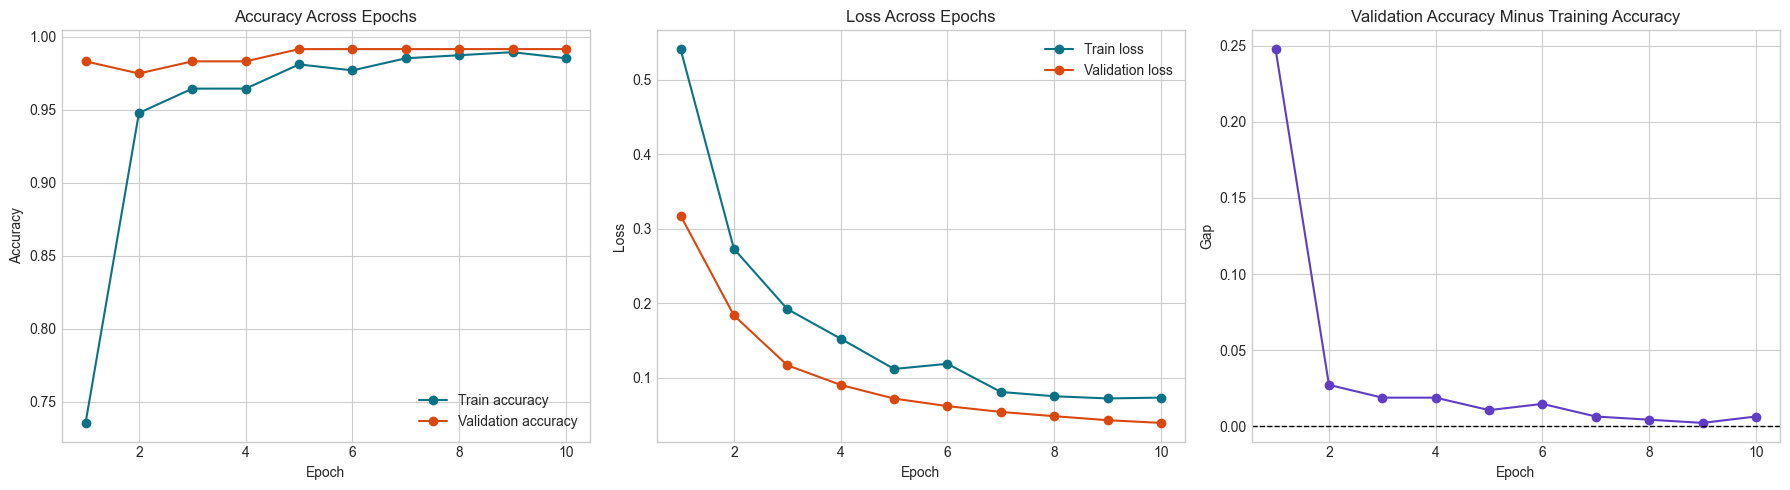

,epoch,accuracy,val_accuracy,loss,val_loss,val_minus_train_accuracy
0,1,0.7354,0.9833,0.5408,0.3176,0.2479
1,2,0.9479,0.9750,0.2730,0.1837,0.0271
2,3,0.9646,0.9833,0.1923,0.1170,0.0187
3,4,0.9646,0.9833,0.1526,0.0906,0.0187
4,5,0.9812,0.9917,0.1120,0.0723,0.0105
5,6,0.9771,0.9917,0.1189,0.0622,0.0146
6,7,0.9854,0.9917,0.0812,0.0544,0.0063
7,8,0.9875,0.9917,0.0754,0.0487,0.0042
8,9,0.9896,0.9917,0.0725,0.0433,0.0021
9,10,0.9854,0.9917,0.0736,0.0397,0.0063


Best validation accuracy appears at epoch 5.
Interpretation: a small or positive validation-minus-training gap can happen when augmentation and dropout make training batches harder than validation batches.
Interpretation: consistently falling validation loss is a strong sign that the model is not simply memorizing the training set.


In [36]:
history_df = pd.DataFrame({
    "epoch": np.arange(1, len(history_records["accuracy"]) + 1),
    "accuracy": history_records["accuracy"],
    "val_accuracy": history_records["val_accuracy"],
    "loss": history_records["loss"],
    "val_loss": history_records["val_loss"],
})
history_df["val_minus_train_accuracy"] = history_df["val_accuracy"] - history_df["accuracy"]

best_epoch_index = int(history_df["val_accuracy"].idxmax())
best_epoch = int(history_df.loc[best_epoch_index, "epoch"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history_df["epoch"], history_df["accuracy"], marker="o", label="Train accuracy", color="#0b7285")
axes[0].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Validation accuracy", color="#d9480f")
axes[0].set_title("Accuracy Across Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["loss"], marker="o", label="Train loss", color="#0b7285")
axes[1].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss", color="#d9480f")
axes[1].set_title("Loss Across Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["val_minus_train_accuracy"], marker="o", color="#5f3dc4")
axes[2].axhline(0.0, linestyle="--", color="black", linewidth=1)
axes[2].set_title("Validation Accuracy Minus Training Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Gap")

plt.tight_layout()
save_figure(fig, "training_curves.png")
plt.show()

display(history_df.round(4))
print(f"Best validation accuracy appears at epoch {best_epoch}.")
print("Interpretation: a small or positive validation-minus-training gap can happen when augmentation and dropout make training batches harder than validation batches.")
print("Interpretation: consistently falling validation loss is a strong sign that the model is not simply memorizing the training set.")


## 7. Validation Performance and Error Analysis

Accuracy alone does not tell the full story, so the next cells measure class-wise performance, inspect the confusion matrix, and look at prediction confidence.

For face recognition, this matters because a model can look excellent overall while still failing on one identity, low-light samples, or borderline cases.


In [37]:
evaluation = model.evaluate(val_eval_dataset, verbose=0, return_dict=True)

all_images = []
all_labels = []
all_probabilities = []
for batch_images, batch_labels in val_eval_dataset:
    batch_probabilities = model.predict(batch_images, verbose=0)
    all_images.append(batch_images.numpy().astype("uint8"))
    all_labels.append(batch_labels.numpy())
    all_probabilities.append(batch_probabilities)

val_images = np.concatenate(all_images, axis=0)
true_labels = np.concatenate(all_labels, axis=0)
predicted_probabilities = np.concatenate(all_probabilities, axis=0)
predicted_labels = predicted_probabilities.argmax(axis=1)
predicted_confidence = predicted_probabilities.max(axis=1)
probability_margin = np.sort(predicted_probabilities, axis=1)[:, -1] - np.sort(predicted_probabilities, axis=1)[:, -2]

ordered_file_paths = sorted(str(path) for path in VAL_DIR.rglob("*") if path.is_file())
results_df = pd.DataFrame({
    "file_path": ordered_file_paths,
    "true_label_index": true_labels,
    "predicted_label_index": predicted_labels,
    "true_label_name": [class_names[index] for index in true_labels],
    "predicted_label_name": [class_names[index] for index in predicted_labels],
    "confidence": predicted_confidence,
    "margin": probability_margin,
    "correct": predicted_labels == true_labels,
})

correct_predictions = int(results_df["correct"].sum())
incorrect_predictions = int((~results_df["correct"]).sum())

print(f"Validation accuracy: {evaluation['accuracy']:.4f}")
print(f"Validation loss:     {evaluation['loss']:.4f}")
print(f"Correct predictions: {correct_predictions}")
print(f"Incorrect predictions: {incorrect_predictions}")
display(results_df.head().round(4))


Validation accuracy: 0.9917
Validation loss:     0.0397
Correct predictions: 119
Incorrect predictions: 1


,file_path,true_label_index,predicted_label_index,true_label_name,predicted_label_name,confidence,margin,correct
0,C:\Users\User\Downloads\THIRD YEAR - SE\summer...,0,0,anton,anton,0.9858,0.9716,True
1,C:\Users\User\Downloads\THIRD YEAR - SE\summer...,0,0,anton,anton,0.9540,0.9080,True
2,C:\Users\User\Downloads\THIRD YEAR - SE\summer...,0,0,anton,anton,0.9930,0.9859,True
3,C:\Users\User\Downloads\THIRD YEAR - SE\summer...,0,0,anton,anton,0.9871,0.9741,True
4,C:\Users\User\Downloads\THIRD YEAR - SE\summer...,0,0,anton,anton,0.9990,0.9981,True


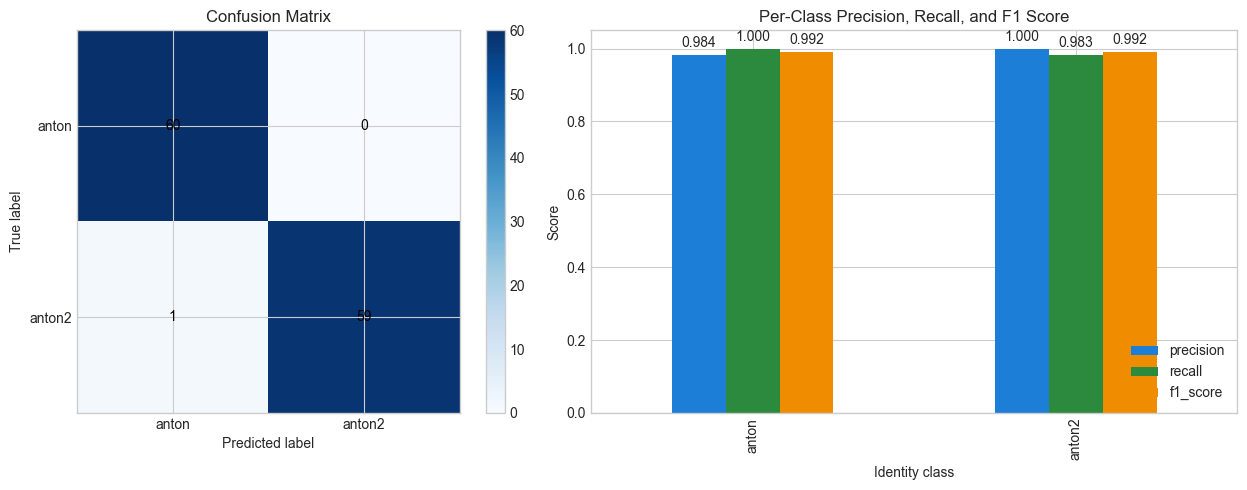

,class_name,support,precision,recall,f1_score
0,anton,60,0.9836,1.0000,0.9917
1,anton2,60,1.0000,0.9833,0.9916


Interpretation: strong diagonal values in the confusion matrix mean the model is assigning each face to the correct person most of the time.
Interpretation: if one class had much lower recall than the other, that would suggest the model is systematically missing that person.


In [38]:
confusion_matrix = build_confusion_matrix(true_labels, predicted_labels, num_classes)
metrics_df = build_class_metrics(true_labels, predicted_labels, class_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(axes[0], confusion_matrix, class_names, "Confusion Matrix")

metrics_plot = metrics_df.set_index("class_name")[["precision", "recall", "f1_score"]]
metrics_plot.plot(kind="bar", ax=axes[1], color=["#1c7ed6", "#2b8a3e", "#f08c00"])
axes[1].set_title("Per-Class Precision, Recall, and F1 Score")
axes[1].set_xlabel("Identity class")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0.0, 1.05)
axes[1].legend(loc="lower right")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
save_figure(fig, "validation_metrics.png")
plt.show()

display(metrics_df.round(4))
print("Interpretation: strong diagonal values in the confusion matrix mean the model is assigning each face to the correct person most of the time.")
print("Interpretation: if one class had much lower recall than the other, that would suggest the model is systematically missing that person.")


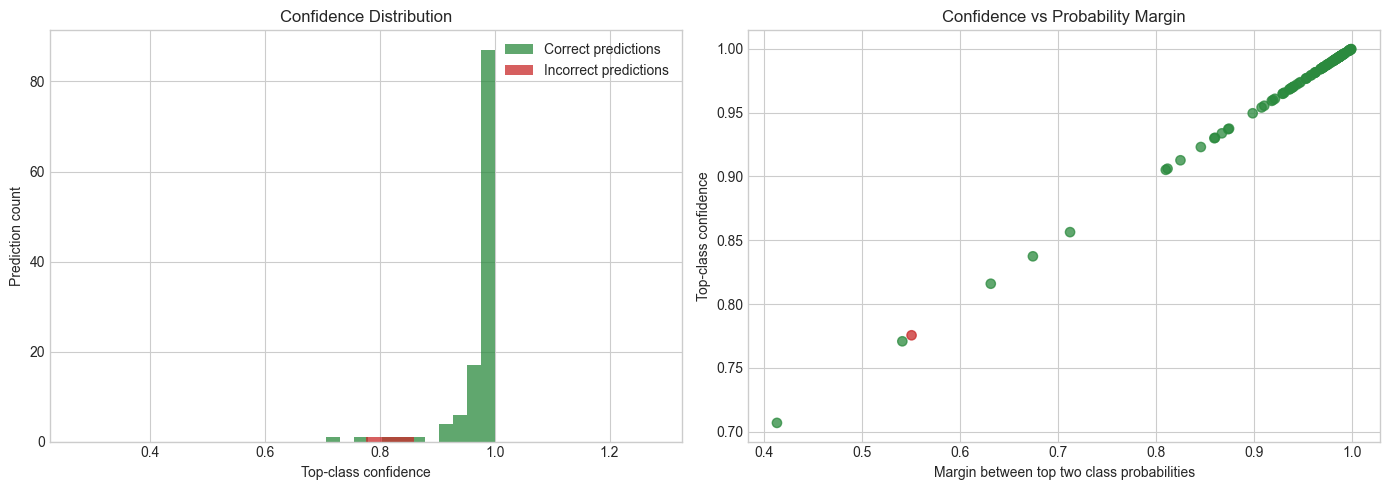

Interpretation: bars packed near 1.0 mean the model is usually very sure of its decision.
Interpretation: points in the upper-right are the easiest samples because the model is both confident and clearly separating the top class from the runner-up.
Interpretation: points closer to the lower-left are the ambiguous cases and are the best place to inspect for future data collection.


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(results_df.loc[results_df["correct"], "confidence"], bins=12, alpha=0.75, color="#2b8a3e", label="Correct predictions")
if incorrect_predictions > 0:
    axes[0].hist(results_df.loc[~results_df["correct"], "confidence"], bins=12, alpha=0.75, color="#c92a2a", label="Incorrect predictions")
axes[0].set_title("Confidence Distribution")
axes[0].set_xlabel("Top-class confidence")
axes[0].set_ylabel("Prediction count")
axes[0].legend()

point_colors = np.where(results_df["correct"], "#2b8a3e", "#c92a2a")
axes[1].scatter(results_df["margin"], results_df["confidence"], c=point_colors, alpha=0.75, s=45)
axes[1].set_title("Confidence vs Probability Margin")
axes[1].set_xlabel("Margin between top two class probabilities")
axes[1].set_ylabel("Top-class confidence")

plt.tight_layout()
save_figure(fig, "confidence_analysis.png")
plt.show()
print("Interpretation: bars packed near 1.0 mean the model is usually very sure of its decision.")
print("Interpretation: points in the upper-right are the easiest samples because the model is both confident and clearly separating the top class from the runner-up.")
print("Interpretation: points closer to the lower-left are the ambiguous cases and are the best place to inspect for future data collection.")


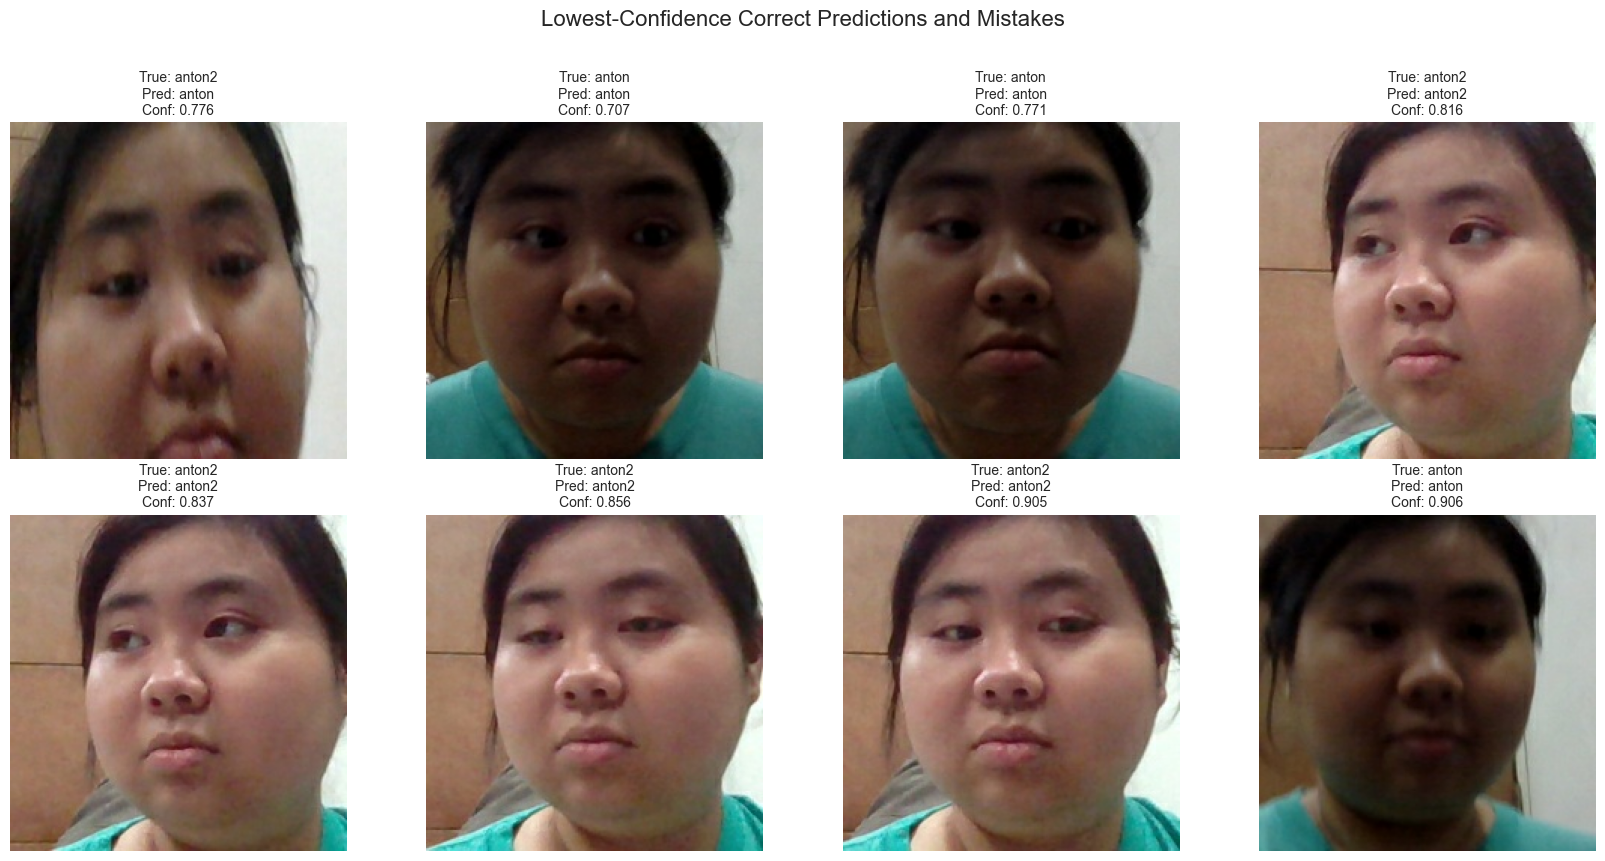

Interpretation: low-confidence correct images reveal the decision boundary, while red-bordered mistakes show exactly where the model still struggles.


In [40]:
mistake_examples = results_df.loc[~results_df["correct"]].copy()
low_confidence_correct = results_df.loc[results_df["correct"]].nsmallest(7, "confidence").copy()
focus_examples = pd.concat([mistake_examples, low_confidence_correct], ignore_index=False).head(8)

if focus_examples.empty:
    print("No edge cases were available to visualize.")
else:
    columns = 4
    rows = math.ceil(len(focus_examples) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4.2 * columns, 4.2 * rows))
    axes = np.atleast_1d(axes).reshape(rows, columns)
    for axis in axes.ravel():
        axis.axis("off")
    for plot_index, (example_index, example_row) in enumerate(focus_examples.iterrows()):
        axis = axes.ravel()[plot_index]
        axis.imshow(val_images[int(example_index)])
        border_color = "#2b8a3e" if example_row["correct"] else "#c92a2a"
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(3)
            spine.set_color(border_color)
        axis.set_title(f"True: {example_row['true_label_name']}\nPred: {example_row['predicted_label_name']}\nConf: {example_row['confidence']:.3f}", fontsize=10)
        axis.axis("off")
    fig.suptitle("Lowest-Confidence Correct Predictions and Mistakes", fontsize=16, y=1.02)
    plt.tight_layout()
    save_figure(fig, "prediction_examples.png")
    plt.show()

print("Interpretation: low-confidence correct images reveal the decision boundary, while red-bordered mistakes show exactly where the model still struggles.")


## 8. What This Model Does Well

Based on the charts above, this model performs strongly because it combines a balanced two-class dataset with a pre-trained deep visual backbone and lightweight classification head.

The summary cell below converts the main results into short talking points you can reuse in your report or presentation.


In [41]:
summary_rows = [
    {"metric": "Training images", "value": train_file_count},
    {"metric": "Validation images", "value": val_file_count},
    {"metric": "Classes", "value": num_classes},
    {"metric": "Validation accuracy", "value": round(float(evaluation["accuracy"]), 4)},
    {"metric": "Validation loss", "value": round(float(evaluation["loss"]), 4)},
    {"metric": "Correct validation predictions", "value": correct_predictions},
    {"metric": "Incorrect validation predictions", "value": incorrect_predictions},
    {"metric": "Mean confidence on correct predictions", "value": round(float(results_df.loc[results_df["correct"], "confidence"].mean()), 4)},
    {"metric": "Mean confidence on incorrect predictions", "value": round(float(results_df.loc[~results_df["correct"], "confidence"].mean()), 4) if incorrect_predictions else "n/a"},
    {"metric": "Best validation epoch from history", "value": best_epoch},
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
print("- The model separates the two known identities very cleanly, as shown by the nearly perfect diagonal confusion matrix.")
print("- Validation accuracy stays high while validation loss keeps dropping, which suggests stable generalization instead of obvious overfitting.")
print("- The dataset is balanced across both classes, so strong accuracy is less likely to come from simply favoring one person more often.")
print("- EfficientNetV2B0 provides strong pre-trained facial feature extraction, letting the classifier perform well even with a modest dataset size.")


,metric,value
0,Training images,480.0000
1,Validation images,120.0000
2,Classes,2.0000
3,Validation accuracy,0.9917
4,Validation loss,0.0397
5,Correct validation predictions,119.0000
6,Incorrect validation predictions,1.0000
7,Mean confidence on correct predictions,0.9740
8,Mean confidence on incorrect predictions,0.7755
9,Best validation epoch from history,5.0000


- The model separates the two known identities very cleanly, as shown by the nearly perfect diagonal confusion matrix.
- Validation accuracy stays high while validation loss keeps dropping, which suggests stable generalization instead of obvious overfitting.
- The dataset is balanced across both classes, so strong accuracy is less likely to come from simply favoring one person more often.
- EfficientNetV2B0 provides strong pre-trained facial feature extraction, letting the classifier perform well even with a modest dataset size.


## 9. Optimization Opportunities and Why They Help

The current model already performs very well, but there are still realistic ways to make it more robust. The goal now is not just higher accuracy on this dataset; it is better reliability on new lighting, new angles, partial occlusion, or real kiosk camera noise.


In [42]:
optimization_df = pd.DataFrame([
    {"optimization": "Fine-tune the top EfficientNet layers with a very low learning rate", "why_it_helps": "Lets the backbone adapt from generic ImageNet features to your specific faces and camera domain.", "expected_contribution": "Usually improves edge cases such as unusual angles, expression changes, or lighting shifts."},
    {"optimization": "Keep EarlyStopping and ReduceLROnPlateau enabled", "why_it_helps": "Stops wasted training and lowers the learning rate when progress slows down.", "expected_contribution": "Helps the model settle into a better minimum while reducing overfitting risk."},
    {"optimization": "Collect harder training images for each person", "why_it_helps": "Adds variation in distance, head tilt, shadows, glasses, and background clutter.", "expected_contribution": "Improves real-world robustness more than simply adding more easy duplicates."},
    {"optimization": "Introduce an unknown-face rejection threshold", "why_it_helps": "Softmax always chooses a known class, even for strangers, unless you guard against low-confidence predictions.", "expected_contribution": "Reduces false acceptance by rejecting low-confidence or ambiguous faces during deployment."},
    {"optimization": "Use face alignment or stronger preprocessing", "why_it_helps": "More consistent eye, nose, and mouth placement makes the classifier compare faces more fairly.", "expected_contribution": "Improves stability when the kiosk camera captures slightly rotated or off-center faces."},
    {"optimization": "Consider embedding-based face recognition for larger class counts", "why_it_helps": "Metric-learning embeddings scale better when you move beyond a very small fixed set of identities.", "expected_contribution": "Makes future expansion easier if the kiosk later needs many registered users or one-shot enrollment."},
])
display(optimization_df)


,optimization,why_it_helps,expected_contribution
0,Fine-tune the top EfficientNet layers with a v...,Lets the backbone adapt from generic ImageNet ...,Usually improves edge cases such as unusual an...
1,Keep EarlyStopping and ReduceLROnPlateau enabled,Stops wasted training and lowers the learning ...,Helps the model settle into a better minimum w...
2,Collect harder training images for each person,"Adds variation in distance, head tilt, shadows...",Improves real-world robustness more than simpl...
3,Introduce an unknown-face rejection threshold,"Softmax always chooses a known class, even for...",Reduces false acceptance by rejecting low-conf...
4,Use face alignment or stronger preprocessing,"More consistent eye, nose, and mouth placement...",Improves stability when the kiosk camera captu...
5,Consider embedding-based face recognition for ...,Metric-learning embeddings scale better when y...,Makes future expansion easier if the kiosk lat...


## 10. Save and Export Deliverables

This final section exports the analysis tables so you can reference them outside the notebook. The markdown companion files in the same folder are meant for your own manual interpretation and reporting.


In [43]:
history_df.to_csv(ARTIFACT_DIR / "history_metrics.csv", index=False)
metrics_df.to_csv(ARTIFACT_DIR / "class_metrics.csv", index=False)
results_df.to_csv(ARTIFACT_DIR / "validation_predictions.csv", index=False)

analysis_snapshot = {
    "model_path": str(MODEL_SAVE_PATH),
    "train_images": int(train_file_count),
    "validation_images": int(val_file_count),
    "classes": class_names,
    "validation_accuracy": float(evaluation["accuracy"]),
    "validation_loss": float(evaluation["loss"]),
    "correct_predictions": correct_predictions,
    "incorrect_predictions": incorrect_predictions,
    "history_source": history_source,
}

import json
with open(ARTIFACT_DIR / "analysis_summary.json", "w", encoding="utf-8") as summary_file:
    json.dump(analysis_snapshot, summary_file, indent=2)

print("Saved analysis artifacts:")
for output_path in sorted(ARTIFACT_DIR.iterdir()):
    print(f"- {output_path}")


Saved analysis artifacts:
- C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\scripts\training\artifacts\model_2_analysis\analysis_summary.json
- C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\scripts\training\artifacts\model_2_analysis\class_metrics.csv
- C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\scripts\training\artifacts\model_2_analysis\confidence_analysis.png
- C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\scripts\training\artifacts\model_2_analysis\dataset_class_balance.png
- C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\scripts\training\artifacts\model_2_analysis\history_metrics.csv
- C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\scripts\training\artifacts\model_2_analysis\image_statistics.png
- C:\Users\User\Downloads\THIRD YEAR - SE\summer\ml-finals\backend\scripts\training\artifacts\model_2_analysis\prediction_examples.png
- C:\Users\User\Downloads\THIRD YEAR - SE\